In [31]:
import pandas as pd

real_df = pd.read_csv(
    '../datasets/online-retail-ii-cleaned.csv.zstd', 
    compression='zstd', 
    sep=';'
)


df = real_df.copy()

print(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1033036 entries, 0 to 1033035
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   InvoiceID          1033036 non-null  str    
 1   StockCode          1033036 non-null  str    
 2   Description        1033036 non-null  str    
 3   Quantity           1033036 non-null  int64  
 4   InvoiceDate        1033036 non-null  str    
 5   Price              1033036 non-null  float64
 6   CustomerID         1033036 non-null  int64  
 7   Country            1033036 non-null  str    
 8   IsGuest            1033036 non-null  bool   
 9   Hour               1033036 non-null  int64  
 10  Year               1033036 non-null  int64  
 11  Month              1033036 non-null  int64  
 12  Day                1033036 non-null  int64  
 13  Week               1033036 non-null  int64  
 14  DayName            1033036 non-null  str    
 15  MonthName          1033036 non-null  str   

,InvoiceID,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,IsGuest,Hour,...,Week,DayName,MonthName,IsNegQty,IsNegPrice,IsCanceled,IsAdjusted,TotalPrice,IsQuantityOutlier,IsPriceOutlier
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01,6.95,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,83.4,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01,6.75,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,81.0,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01,6.75,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,81.0,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01,2.10,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,100.8,True,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01,1.25,13085,United Kingdom,False,7,...,49,Tuesday,December,False,False,False,False,30.0,True,False


In [32]:
df.isna().sum()

InvoiceID            0
StockCode            0
Description          0
Quantity             0
InvoiceDate          0
Price                0
CustomerID           0
Country              0
IsGuest              0
Hour                 0
Year                 0
Month                0
Day                  0
Week                 0
DayName              0
MonthName            0
IsNegQty             0
IsNegPrice           0
IsCanceled           0
IsAdjusted           0
TotalPrice           0
IsQuantityOutlier    0
IsPriceOutlier       0
dtype: int64

In [33]:
print(df.duplicated().sum())
display(df[df.duplicated()])

2


,InvoiceID,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,IsGuest,Hour,...,Week,DayName,MonthName,IsNegQty,IsNegPrice,IsCanceled,IsAdjusted,TotalPrice,IsQuantityOutlier,IsPriceOutlier
41180,492807,21813,GARLAND WITH STARS AND BELLS,6,2009-12-20,4.95,17211,United Kingdom,False,12,...,51,Sunday,December,False,False,False,False,29.7,False,False
839988,567183,22659,LUNCH BOX I LOVE LONDON,2,2011-09-18,1.95,14769,United Kingdom,False,15,...,37,Sunday,September,False,False,False,False,3.9,False,False


In [34]:
df = df[~df.duplicated()]
df.duplicated().sum()

np.int64(0)

In [35]:
# 1. Buang yang negatif, outlier, dan guest
df_clean = df[
    (~df['IsNegQty']) & 
    (~df['IsNegPrice']) & 
    (~df['IsQuantityOutlier']) & 
    (~df['IsPriceOutlier']) &
    (~df['IsGuest']) &
    (~df['IsCanceled']) # Opsional: jika ingin fokus ke transaksi sukses saja
].copy()

# 2. Pastikan kolom tanggal dalam format datetime (untuk Recency)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [36]:
# Tentukan tanggal referensi (satu hari setelah transaksi terakhir)
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Agregasi ke level Customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceID': 'nunique',                                 # Frequency
    'TotalPrice': 'sum'                                     # Monetary
}).reset_index()

# Rename kolom agar rapi
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [37]:
import numpy as np

# Ambil kolom numerik saja (buang CustomerID)
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1)

# Lihat perbedaannya (opsional)
rfm_log.describe()

,Recency,Frequency,Monetary
count,5654.000000,5654.000000,5654.000000
mean,4.482460,1.516442,6.345335
std,1.523343,0.784630,1.346892
min,0.693147,0.693147,0.000000
25%,3.332205,0.693147,5.419583
50%,4.584967,1.386294,6.333581
75%,5.942799,1.945910,7.255199
max,6.606650,5.905362,11.976064


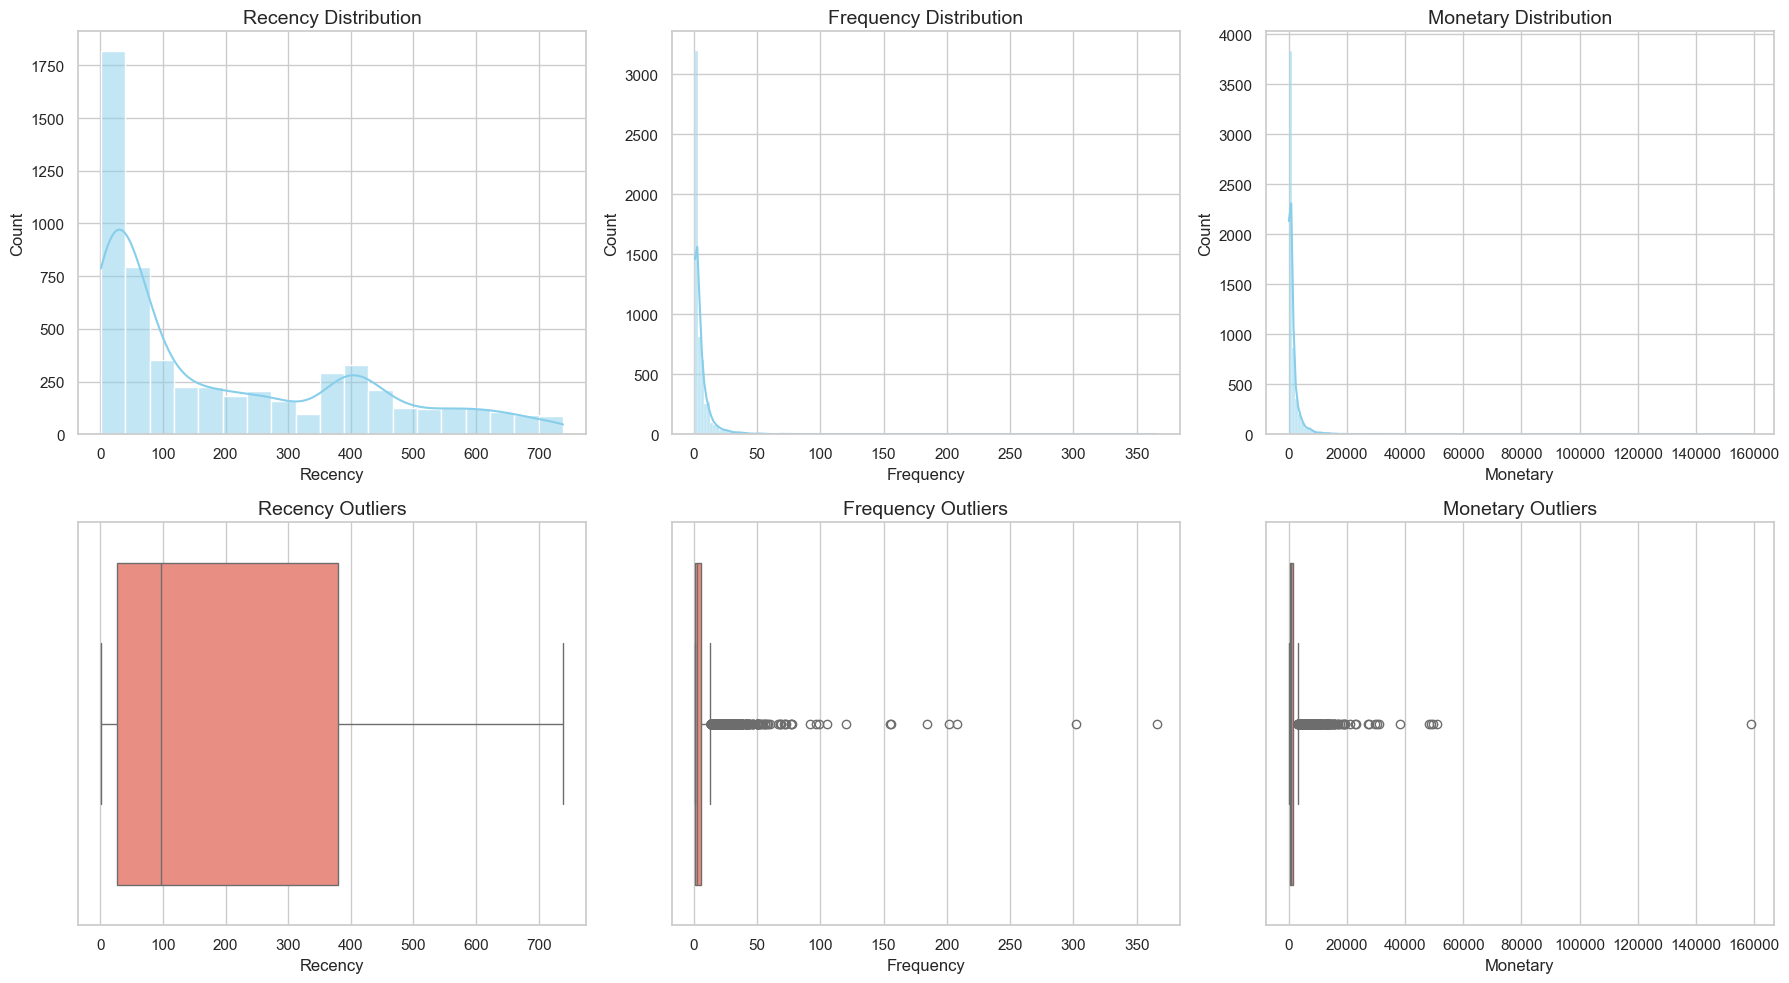

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set tema visualisasi
sns.set_theme(style="whitegrid")

# Buat subplots: 2 baris (Histplot & Boxplot), 3 kolom (R, F, M)
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

features = ['Recency', 'Frequency', 'Monetary']

for i, col in enumerate(features):
    # Baris 1: Histplot (Distribusi)
    sns.histplot(rfm[col], kde=True, ax=ax[0, i], color='skyblue')
    ax[0, i].set_title(col + ' Distribution', fontsize=14)
    
    # Baris 2: Boxplot (Outlier)
    sns.boxplot(x=rfm[col], ax=ax[1, i], color='salmon')
    ax[1, i].set_title(col + ' Outliers', fontsize=14)

plt.tight_layout()
plt.show()

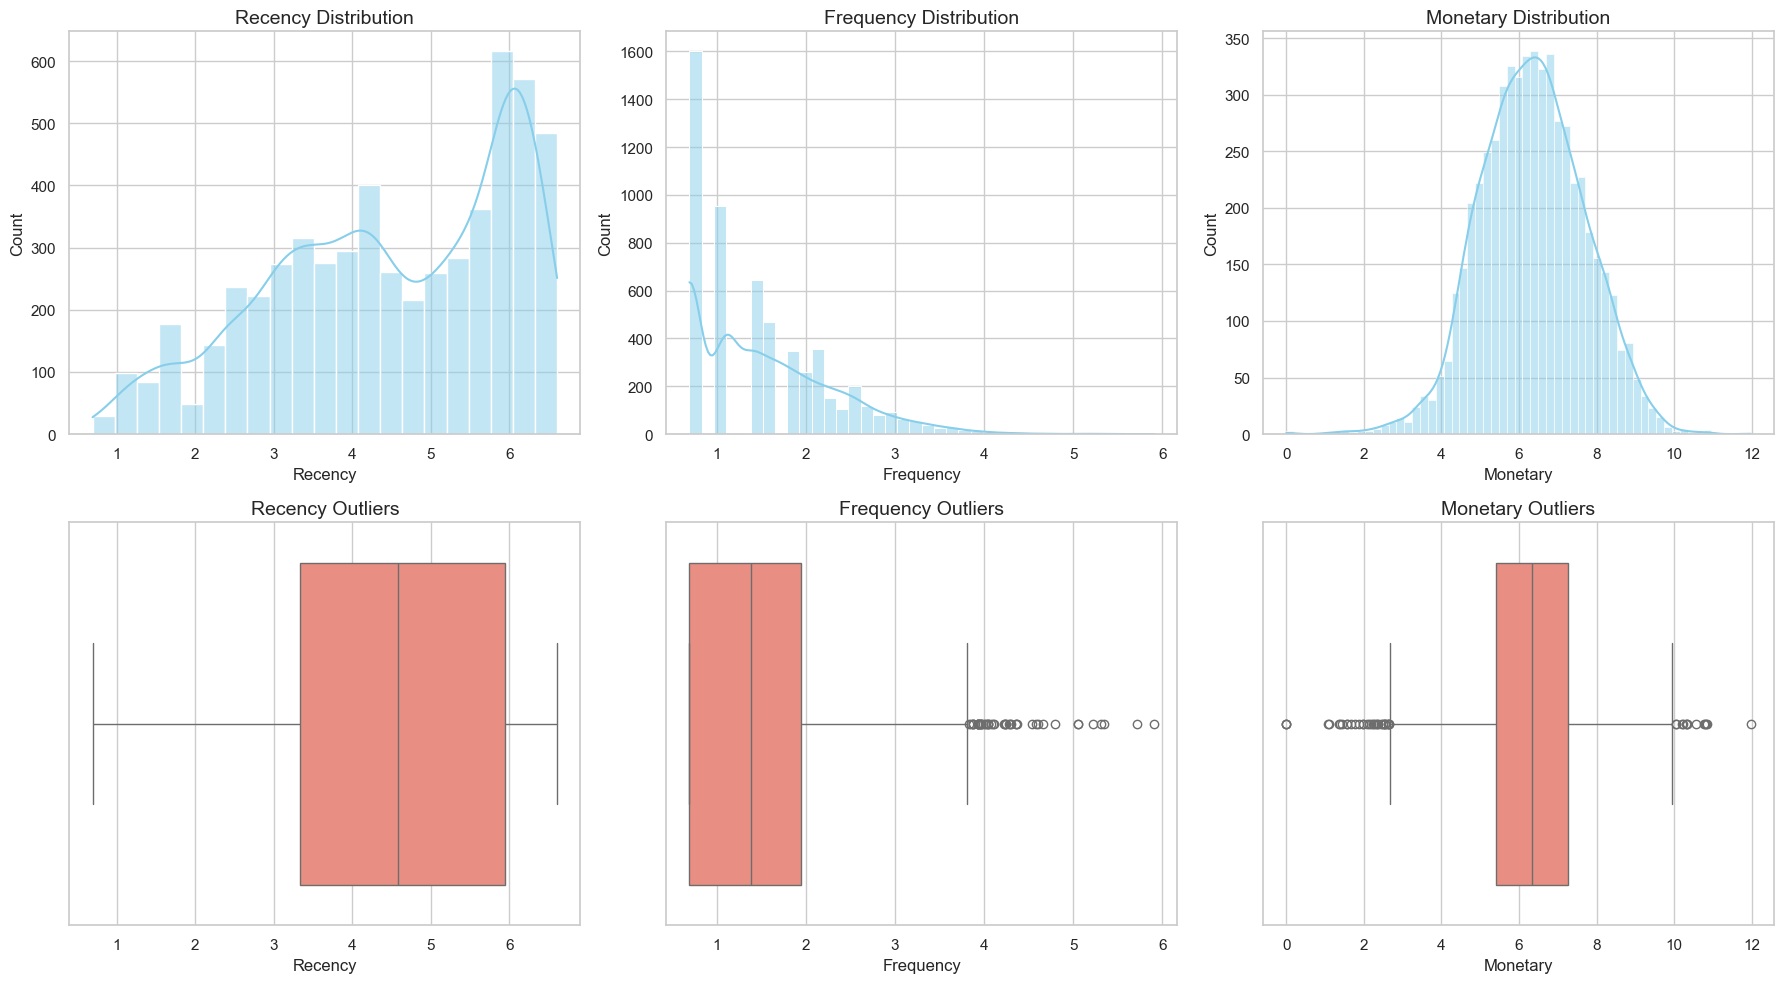

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set tema visualisasi
sns.set_theme(style="whitegrid")

# Buat subplots: 2 baris (Histplot & Boxplot), 3 kolom (R, F, M)
fig, ax = plt.subplots(2, 3, figsize=(18, 10))

features = ['Recency', 'Frequency', 'Monetary']

for i, col in enumerate(features):
    # Baris 1: Histplot (Distribusi)
    sns.histplot(rfm_log[col], kde=True, ax=ax[0, i], color='skyblue')
    ax[0, i].set_title(col + ' Distribution', fontsize=14)
    
    # Baris 2: Boxplot (Outlier)
    sns.boxplot(x=rfm_log[col], ax=ax[1, i], color='salmon')
    ax[1, i].set_title(col + ' Outliers', fontsize=14)

plt.tight_layout()
plt.show()

In [40]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Ubah kembali ke DataFrame agar enak dilihat
df_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

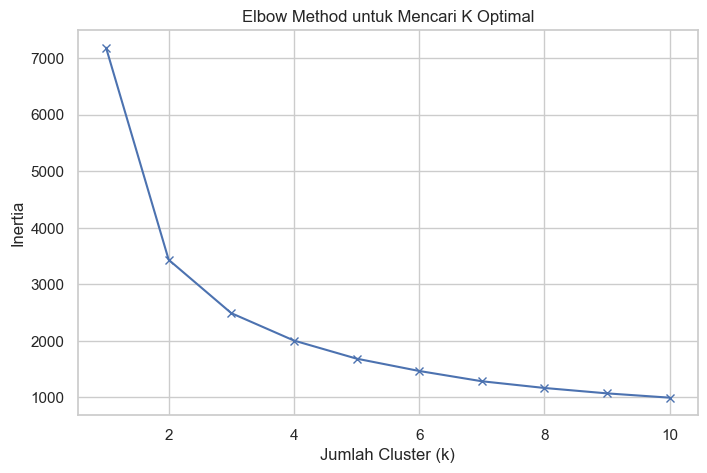

In [41]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Mencari K Optimal')
plt.show()

In [42]:
from sklearn.metrics import silhouette_score

for k in range(2,8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}") # ambil dengan nilai tertinggi

k=2, silhouette=0.439
k=3, silhouette=0.352
k=4, silhouette=0.357
k=5, silhouette=0.324
k=6, silhouette=0.298
k=7, silhouette=0.305


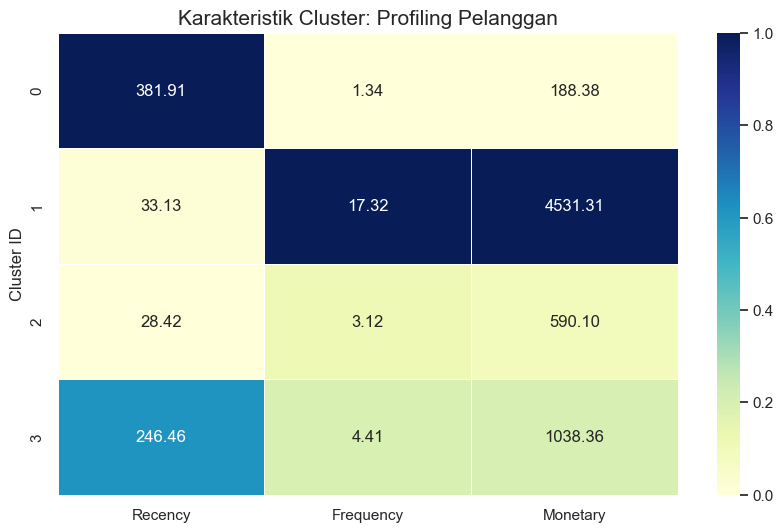

In [43]:
# 1. Jalankan K-Means dengan K pilihanmu (contoh k=4)
k_optimal = 4 
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(df_scaled)

# 2. Cek rata-rata tiap cluster untuk interpretasi
cluster_analysis = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

# 1. Ambil hanya nilai 'mean' dan buang kolom 'count'
heatmap_data = cluster_analysis.drop(columns=('Monetary', 'count'))

# 2. Flatten Multi-index columns (menghilangkan level 'mean')
heatmap_data.columns = ['Recency', 'Frequency', 'Monetary']

# 3. Normalisasi data (0-1) khusus untuk pewarnaan saja
# Ini supaya warna 'Frequency' yang kecil tidak kalah terang dengan 'Monetary' yang besar
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

# 4. Plot Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data=heatmap_norm, 
            annot=heatmap_data, # Tampilkan angka asli
            fmt='.2f', 
            cmap='YlGnBu', 
            linewidths=.5)

plt.title('Karakteristik Cluster: Profiling Pelanggan', fontsize=15)
plt.ylabel('Cluster ID')
plt.show()

In [44]:
import plotly.express as px

# Visualisasi 3D menggunakan Plotly (interaktif)
fig = px.scatter_3d(rfm, x='Recency', y='Frequency', z='Monetary',
                    color='Cluster', opacity=0.7,
                    title='3D Visualization of Customer Segments')
fig.show()